# Support Vector Machine (SVM): Theory

Support Vector Machine (SVM) is a supervised learning algorithm used for classification and regression. It finds the decision boundary (hyperplane) that maximizes the margin — the distance between the hyperplane and the nearest training points from each class (these points are called support vectors).

Key concepts:
- Margin: larger margins generally lead to better generalization.
- Support vectors: data points that lie closest to the decision boundary and determine its position.
- Linear SVM: separates classes with a linear hyperplane when data is linearly separable.
- Soft margin (regularization): allows some misclassifications to handle non-separable data. Controlled by parameter `C` (small C → wider margin, more regularization; large C → narrower margin, fewer misclassifications).

Kernel trick:
- Maps input features into a higher-dimensional space to make data linearly separable there without computing the mapping explicitly.
- Common kernels: linear, polynomial, radial basis function (RBF / Gaussian), sigmoid.
- Kernel hyperparameters (e.g., `gamma` for RBF) control decision boundary flexibility.

Multiclass:
- SVM is inherently binary; multiclass handled via strategies like One-vs-Rest or One-vs-One.

Strengths and limitations:
- Strengths: effective in high-dimensional spaces, robust to overfitting with proper regularization, works well with clear margins.
- Limitations: can be slow on large datasets, choice and tuning of kernel/hyperparameters matter, less interpretable than simple linear models.

Common hyperparameters to tune: `C`, `kernel`, `gamma` (for RBF), `degree` (for polynomial).

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [25]:
iris=load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [26]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [27]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [28]:
df["target"]=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [29]:
df["flower_name"]=df.target.apply(lambda x:iris.target_names[x])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [30]:
df0=df[df.target==0]
df1=df[df.target==1]
df2=df[df.target==2]

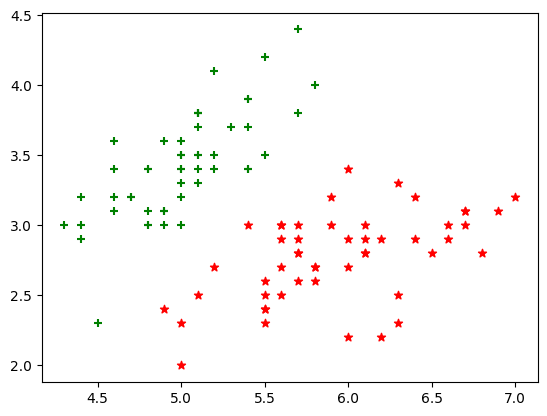

In [31]:
plt.scatter(df0["sepal length (cm)"],df0["sepal width (cm)"],marker="+",color="green")
plt.scatter(df1["sepal length (cm)"],df1["sepal width (cm)"],marker="*",color="red")

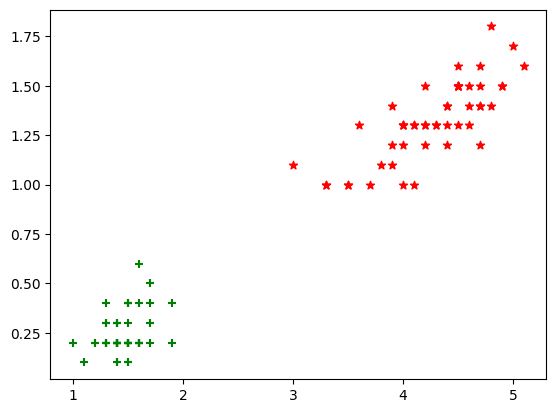

In [32]:
plt.scatter(df0["petal length (cm)"],df0["petal width (cm)"],marker="+",color="green")
plt.scatter(df1["petal length (cm)"],df1["petal width (cm)"],marker="*",color="red")

In [ ]:
X=df.drop(['target','flower_name'],axis="columns")
Y=df.target

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [34]:
X_Train,X_Test,Y_Train,Y_Test=train_test_split(X,Y,test_size=0.2)

In [35]:
len(X_Train)

120

In [36]:
len(X_Test)

30

In [37]:
model=SVC()

In [41]:
model.fit(X_Train,Y_Train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [42]:
model.score(X_Test,Y_Test)

0.9666666666666667